# PHÂN TÍCH ĐIỂM THI THPT NĂM 2026

## Mục tiêu, phạm vi và quy ước phân tích

Notebook tập trung phân tích kết quả của hai môn bắt buộc là **Toán** và **Ngữ văn** trong dữ liệu điểm thi THPT năm 2026.

Các nội dung chính gồm:

- kiểm tra cấu trúc và chất lượng dữ liệu;
- thống kê số lượng, tỷ lệ điểm bị thiếu;
- phân tích trung bình, trung vị, tứ phân vị và khoảng IQR;
- kiểm tra ngoại lai theo quy tắc IQR;
- so sánh hai phương án xử lý dữ liệu `NULL`;
- trực quan hóa phân phối điểm Toán và Ngữ văn;
- tính xác suất thực nghiệm thí sinh có điểm dưới 5;
- phân nhóm đồng thời hai môn theo các mức `< 5`, `= 5` và `> 5`;
- đo mức độ liên hệ tuyến tính giữa Toán và Ngữ văn bằng hệ số Pearson;
- kiểm tra thử nghiệm giả định liên quan đến biến `TongDiem`.

### Phạm vi dữ liệu

- Đơn vị quan sát là **một thí sinh**.
- Bảng được sử dụng là `dbo.du_lieu_diem_thi_2026`.
- Tập dữ liệu có tổng cộng **1.208.863 bản ghi**.
- Có **1.180.873 thí sinh có đầy đủ cả điểm Toán và Ngữ văn**.
- Các phép phân tích đồng thời hai môn chỉ sử dụng những thí sinh có đủ cả hai điểm.

### Quy ước phân nhóm

- `< 5`: điểm nhỏ hơn 5;
- `= 5`: điểm bằng đúng 5;
- `> 5`: điểm lớn hơn 5.

Điểm bằng đúng 5 được tách thành nhóm riêng, không gộp vào nhóm dưới 5 hoặc trên 5. Cách chia này giúp các nhóm không bị trùng lặp và không bỏ sót dữ liệu.

> **Lưu ý:** Các kết quả trong notebook phản ánh đặc điểm của tập dữ liệu đang phân tích. Không nên sử dụng riêng điểm Toán, Ngữ văn hoặc phép tính thử nghiệm từ `TongDiem` để kết luận chính thức một thí sinh đỗ, trượt hay thuộc một mức học lực cụ thể.

## 1. Kết nối cơ sở dữ liệu và kiểm tra cấu trúc bảng

In [1]:
from sqlalchemy import create_engine
import pyodbc
import pandas as pd
from sqlalchemy import text
import warnings
import urllib
from sqlalchemy import exc
from dotenv import load_dotenv
import os
# 1. Khai báo thông tin kết nối
load_dotenv(dotenv_path='doten.env')
raw_conn_str = os.getenv("DB_CONN_STR")

# 2. MÃ HÓA chuỗi kết nối 
params = urllib.parse.quote_plus(raw_conn_str)
connection_url = f"mssql+pyodbc:///?odbc_connect={params}"

# 3. Tạo engine
engine = create_engine(connection_url)

In [2]:
query=r''' 
        SELECT TOP 1 
            *  
        FROM 
            [dbo].[du_lieu_diem_thi_2026]'''
df=pd.read_sql(query,engine)
print('Dưới đây là các cột có trong data')
print(' ------------------------------ ')
df.columns.to_list()

Dưới đây là các cột có trong data
 ------------------------------ 


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\pandas\io\sql.py:1636: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


['SBD',
 'Nam',
 'Tinh',
 'SBD_New',
 'Toan',
 'NguVan',
 'VatLy',
 'HoaHoc',
 'SinhHoc',
 'LichSu',
 'DiaLy',
 'KinhTePhapLuat',
 'TinHoc',
 'CongNgheCongNghiep',
 'CongNgheNongNghiep',
 'NgoaiNgu',
 'MaMonNgoaiNgu',
 'TongDiem',
 'KhoiA',
 'KhoiA1',
 'KhoiB',
 'KhoiC',
 'KhoiD',
 'KhoiA02',
 'KhoiC01',
 'KhoiD07']

## 2. Kiểm tra chất lượng dữ liệu

Phần này kiểm tra số điểm bị thiếu và các trường hợp thiếu đồng thời hai môn bắt buộc. Giá trị `NULL` chỉ thể hiện rằng điểm chưa được ghi nhận; nó không đồng nghĩa với điểm 0 và cũng chưa đủ để xác định nguyên nhân thiếu.

### 2.1. Kiểm tra số giá trị `NULL` của môn Toán

In [3]:
check_null=r'''
    select sum(check_null) as sum_null  from  
        (
    select toan,
        case 
        when toan is null  then 1 else 0
        end as check_null
    from 
         [diem_thi_thpt].[dbo].[du_lieu_diem_thi_2026]
         )  as abc'''
sum_null=pd.read_sql(check_null,engine)
print('Dưới đây là tổng số null của cột điểm toán')
print('-----------------------------------------')
sum_null

Dưới đây là tổng số null của cột điểm toán
-----------------------------------------


,sum_null
0,16426


### 2.2. Các thí sinh thiếu đồng thời điểm Toán và Ngữ văn theo mã tỉnh

In [4]:
# thống kê số lượng tỉnh có học sinh không nộp bài toán văn 
query_5 = r'''
        SELECT
            Tinh,
            COUNT(*) AS sum_null
        FROM dbo.du_lieu_diem_thi_2026
        WHERE Toan IS NULL
          AND NguVan IS NULL
        GROUP BY Tinh
        ORDER BY sum_null DESC;
        '''
check_null_toan_van=pd.read_sql(query_5,engine)
check_null_toan_van.head()

,Tinh,sum_null
0,1,19
1,79,11
2,75,4
3,31,4
4,48,4


#### Biểu đồ thiếu đồng thời Toán và Ngữ văn

Biểu đồ thể hiện số trường hợp và tỷ trọng của từng mã tỉnh trong tổng số thí sinh thiếu cả hai môn. Đường nét đứt biểu diễn số trường hợp trung bình trên mỗi mã tỉnh.

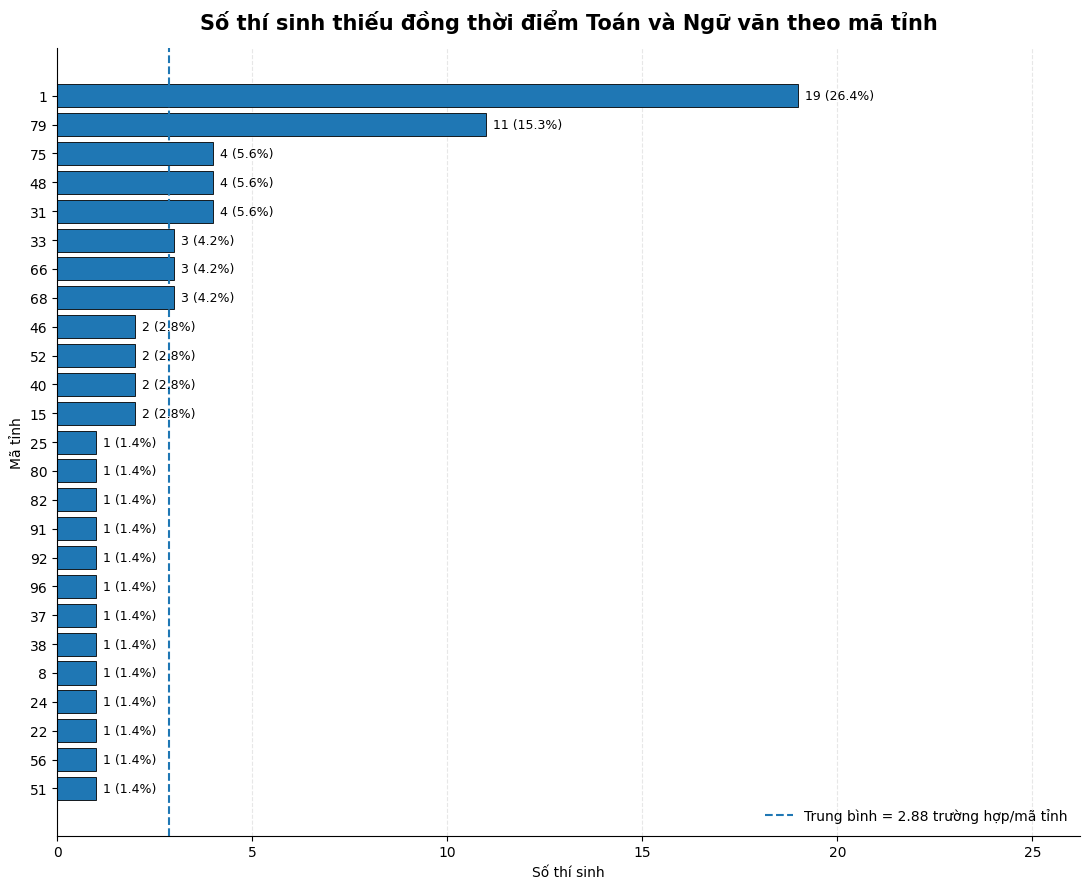

In [5]:
import matplotlib.pyplot as plt

thieu_hai_mon_plot = (
    check_null_toan_van
    .copy()
    .sort_values("sum_null", ascending=True)
)

tong_thieu_hai_mon = thieu_hai_mon_plot["sum_null"].sum()
thieu_hai_mon_plot["ty_le"] = (
    thieu_hai_mon_plot["sum_null"] / tong_thieu_hai_mon * 100
)

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(
    thieu_hai_mon_plot["Tinh"].astype(str),
    thieu_hai_mon_plot["sum_null"],
    edgecolor="black",
    linewidth=0.6
)

trung_binh_moi_tinh = thieu_hai_mon_plot["sum_null"].mean()
ax.axvline(
    trung_binh_moi_tinh,
    linestyle="--",
    linewidth=1.5,
    label=f"Trung bình = {trung_binh_moi_tinh:.2f} trường hợp/mã tỉnh"
)

ax.set_title(
    "Số thí sinh thiếu đồng thời điểm Toán và Ngữ văn theo mã tỉnh",
    fontsize=15,
    fontweight="bold",
    pad=14
)
ax.set_xlabel("Số thí sinh")
ax.set_ylabel("Mã tỉnh")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

for bar, so_luong, ty_le in zip(
    bars,
    thieu_hai_mon_plot["sum_null"],
    thieu_hai_mon_plot["ty_le"]
):
    ax.text(
        bar.get_width() + 0.18,
        bar.get_y() + bar.get_height() / 2,
        f"{int(so_luong)} ({ty_le:.1f}%)",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, thieu_hai_mon_plot["sum_null"].max() * 1.38)
ax.legend(frameon=False, loc="lower right")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()


#### Nhận xét chất lượng dữ liệu

Tập dữ liệu có tổng cộng **1.208.863 thí sinh**. Kết quả kiểm tra cho thấy:

- **16.426 thí sinh thiếu điểm Toán**, chiếm khoảng **1,36%** tổng số bản ghi;
- khoảng **11.636 thí sinh thiếu điểm Ngữ văn**, chiếm khoảng **0,96%**;
- **72 thí sinh thiếu đồng thời cả hai môn**;
- **16.354 thí sinh chỉ thiếu Toán** nhưng vẫn có điểm Ngữ văn;
- **11.564 thí sinh chỉ thiếu Ngữ văn** nhưng vẫn có điểm Toán;
- **1.180.873 thí sinh có đủ cả hai điểm**, chiếm khoảng **97,68%** dữ liệu.

Có **72 trường hợp** thiếu đồng thời Toán và Ngữ văn, phân bố tại **25 mã tỉnh**. Mã tỉnh 1 có **19 trường hợp**, mã tỉnh 79 có **11 trường hợp**; hai mã tỉnh này có tổng cộng 30 trường hợp, chiếm khoảng **41,67%** số trường hợp thiếu cả hai môn.

Tuy nhiên, đây mới là so sánh theo **số lượng tuyệt đối**. Một tỉnh có nhiều thí sinh dự thi hơn có thể có số trường hợp thiếu lớn hơn nhưng tỷ lệ thiếu chưa chắc cao hơn. Để so sánh công bằng, cần tính thêm:

\[
\text{Tỷ lệ thiếu hai môn của tỉnh}
=
\frac{\text{Số thí sinh thiếu cả Toán và Ngữ văn của tỉnh}}
{\text{Tổng số thí sinh của tỉnh}}
\times 100
\]

Dữ liệu hiện chỉ thể hiện `NULL`, vì vậy chưa thể kết luận thí sinh vắng thi, không đăng ký, được miễn thi, bị đình chỉ, bị hủy kết quả hay dữ liệu bị thiếu khi thu thập. Các bản ghi thiếu nên được loại khỏi phép tính điểm tương ứng nhưng vẫn phải được báo cáo riêng trong phần chất lượng dữ liệu.

Ngoài ra, mã tỉnh nên được ánh xạ sang tên tỉnh để kết quả dễ đọc và dễ diễn giải hơn.

## 3. Phân tích môn Toán

### 3.1. Tứ phân vị, trung vị và khoảng IQR

In [6]:
query_iqr=r'''
                
DECLARE @Q1 FLOAT;
DECLARE @Q2 FLOAT;
DECLARE @Q3 FLOAT;
DECLARE @IQR FLOAT;
DECLARE @NguongDuoi FLOAT;
DECLARE @NguongTren FLOAT;

WITH TinhTuPhanVi AS
(
    SELECT
        PERCENTILE_CONT(0.25)
            WITHIN GROUP (ORDER BY Toan)
            OVER () AS Q1,

        PERCENTILE_CONT(0.50)
            WITHIN GROUP (ORDER BY Toan)
            OVER () AS Q2,

        PERCENTILE_CONT(0.75)
            WITHIN GROUP (ORDER BY Toan)
            OVER () AS Q3
    FROM [dbo].[du_lieu_diem_thi_2026]
    WHERE Toan IS NOT NULL
)

SELECT TOP 1
    @Q1 = Q1,
    @Q2 = Q2,
    @Q3 = Q3
FROM TinhTuPhanVi;

SET @IQR = @Q3 - @Q1;
SET @NguongDuoi = @Q1 - 1.5 * @IQR;
SET @NguongTren = @Q3 + 1.5 * @IQR;

SELECT
    @Q1 AS Q1,
    @Q2 AS Q2_TrungVi,
    @Q3 AS Q3,
    @IQR AS IQR,
    @NguongDuoi AS NguongDuoi,
    @NguongTren AS NguongTren;'''
clean_iqr=pd.read_sql(query_iqr,engine)
clean_iqr

,Q1,Q2_TrungVi,Q3,IQR,NguongDuoi,NguongTren
0,4.25,5.5,7.25,3.0,-0.25,11.75


### 3.2. So sánh hai cách xử lý điểm Toán bị thiếu

Hai phương án được so sánh:

1. thay `NULL` bằng trung vị 5,5;
2. bỏ qua `NULL` và chỉ tính trên các điểm quan sát thực tế.

In [7]:
query_3=r'''
        select 
            avg(ISNULL(toan,5.5)) as avg_toan 
        from 
            [dbo].[du_lieu_diem_thi_2026]
        '''
avg_toan_q2=pd.read_sql(query_3,engine)
avg_toan_q2

,avg_toan
0,5.649536


In [8]:
query_4=r'''
        select 
            avg(toan) as avg_toan_tt
        from 
            [dbo].[du_lieu_diem_thi_2026]
        where 
            toan is not null'''
avg_toan_tt=pd.read_sql(query_4,engine)
avg_toan_tt

,avg_toan_tt
0,5.651596


#### Nhận xét về xử lý `NULL` môn Toán

Khi thay điểm Toán bị thiếu bằng trung vị 5,5, điểm trung bình là khoảng **5,6495**. Khi bỏ qua `NULL`, điểm trung bình là khoảng **5,6516**.

Mức chênh lệch là:

\[
5,6516-5,6495\approx0,0021\text{ điểm}
\]

Ảnh hưởng lên trung bình chung là rất nhỏ vì tỷ lệ thiếu thấp và trung vị nằm gần điểm trung bình. Tuy nhiên, điểm được điền không phải điểm thi thực tế. Việc điền trung vị có thể làm dữ liệu tập trung hơn và giảm độ phân tán.

Do đó:

- báo cáo mô tả nên ưu tiên các điểm quan sát thật;
- dữ liệu thiếu nên được thống kê riêng;
- nếu điền trung vị để huấn luyện mô hình, nên thêm một cột đánh dấu bản ghi đã được điền.

### 3.3. Biểu đồ phân bố điểm Toán

Histogram giúp quan sát hình dạng phân phối. Các đường dọc biểu diễn trung bình, trung vị, Q1 và Q3. Mỗi khoảng điểm có độ rộng 0,25 nên biểu đồ thể hiện khá chi tiết sự thay đổi số lượng thí sinh theo từng vùng điểm.

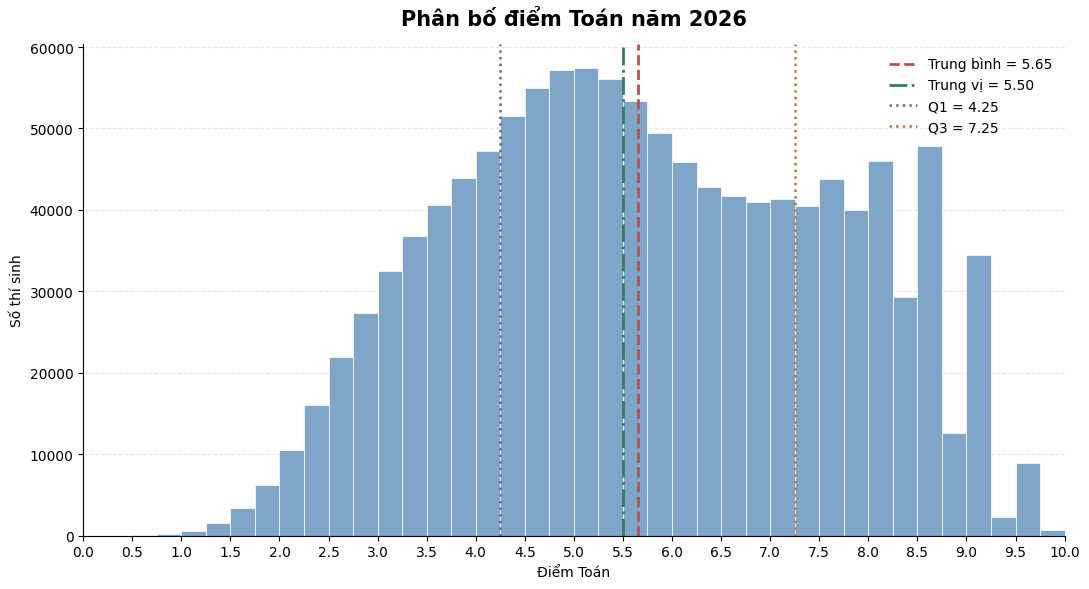

In [9]:
import numpy as np
import matplotlib.pyplot as plt

query_bieu_do_toan = r"""
    SELECT CAST(Toan AS FLOAT) AS Toan
    FROM dbo.du_lieu_diem_thi_2026
    WHERE Toan IS NOT NULL
"""

diem_toan_plot = pd.read_sql(query_bieu_do_toan, engine)["Toan"].dropna()

mean_toan = diem_toan_plot.mean()
median_toan = diem_toan_plot.median()
q1_toan = diem_toan_plot.quantile(0.25)
q3_toan = diem_toan_plot.quantile(0.75)

fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(
    diem_toan_plot,
    bins=np.arange(0, 10.26, 0.25),
    color="#7FA6C9",
    edgecolor="white",
    linewidth=0.5
)

ax.axvline(mean_toan, color="#B5524C", linestyle="--", linewidth=2,
           label=f"Trung bình = {mean_toan:.2f}")
ax.axvline(median_toan, color="#3F7863", linestyle="-.", linewidth=2,
           label=f"Trung vị = {median_toan:.2f}")
ax.axvline(q1_toan, color="#71658C", linestyle=":", linewidth=1.8,
           label=f"Q1 = {q1_toan:.2f}")
ax.axvline(q3_toan, color="#B27A45", linestyle=":", linewidth=1.8,
           label=f"Q3 = {q3_toan:.2f}")

ax.set_title("Phân bố điểm Toán năm 2026", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Điểm Toán")
ax.set_ylabel("Số thí sinh")
ax.set_xlim(0, 10)
ax.set_xticks(np.arange(0, 10.5, 0.5))
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(frameon=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

### 3.4. Box plot điểm Toán

Box plot thể hiện trung vị, khoảng tứ phân vị, hai râu hộp và các điểm nằm ngoài giới hạn theo quy tắc IQR.

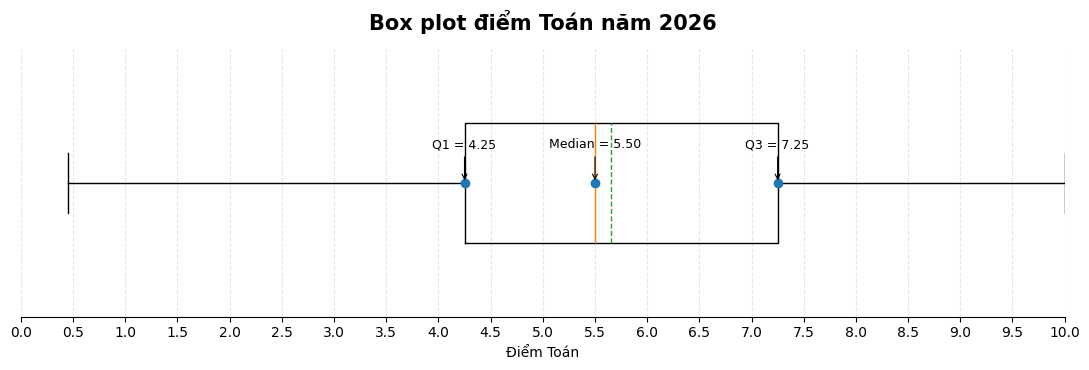

In [10]:
fig, ax = plt.subplots(figsize=(11, 3.8))

ax.boxplot(
    diem_toan_plot,
    vert=False,
    widths=0.45,
    showmeans=True,
    meanline=True,
    showfliers=True
)

ax.scatter(
    [q1_toan, median_toan, q3_toan],
    [1, 1, 1],
    zorder=3
)

for x, nhan in [
    (q1_toan, f"Q1 = {q1_toan:.2f}"),
    (median_toan, f"Median = {median_toan:.2f}"),
    (q3_toan, f"Q3 = {q3_toan:.2f}")
]:
    ax.annotate(
        nhan,
        xy=(x, 1),
        xytext=(0, 25),
        textcoords="offset points",
        ha="center",
        arrowprops={"arrowstyle": "->", "linewidth": 0.8},
        fontsize=9
    )

ax.set_title("Box plot điểm Toán năm 2026", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Điểm Toán")
ax.set_yticks([])
ax.set_xlim(0, 10)
ax.set_xticks(np.arange(0, 10.5, 0.5))
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()


#### Kết luận môn Toán

Trong tổng số **1.208.863 thí sinh**, có **1.192.437 thí sinh có điểm Toán** và **16.426 thí sinh thiếu điểm Toán**.

Các chỉ số chính gồm:

- điểm trung bình: khoảng **5,6516**;
- Q1: **4,25**;
- trung vị: **5,50**;
- Q3: **7,25**;
- IQR: **3,00**;
- ngưỡng dưới IQR: **-0,25**;
- ngưỡng trên IQR: **11,75**.

Khoảng 50% thí sinh có điểm Toán từ **4,25 đến 7,25**. Trung bình cao hơn trung vị khoảng 0,15 điểm, cho thấy các mức điểm cao có thể kéo trung bình tăng nhẹ, nhưng mức chênh lệch không lớn.

Giới hạn IQR được tính như sau:

\[
\text{Ngưỡng dưới}=4,25-1,5\times3=-0,25
\]

\[
\text{Ngưỡng trên}=7,25+1,5\times3=11,75
\]

Vì thang điểm hợp lệ nằm từ 0 đến 10, không có giá trị nào nằm ngoài hai giới hạn này. Do đó, quy tắc IQR không phát hiện ngoại lai môn Toán.

Tuy nhiên, không có ngoại lai theo IQR không đồng nghĩa dữ liệu chắc chắn hoàn toàn sạch. Vẫn cần kiểm tra điểm ngoài miền 0–10, kiểu dữ liệu, số báo danh trùng và các lỗi nghiệp vụ khác.

## 4. Phân tích môn Ngữ văn

### 4.1. So sánh hai cách xử lý điểm Ngữ văn bị thiếu

In [11]:
query_6=r'''
WITH q2_van AS (
            SELECT DISTINCT
                PERCENTILE_CONT(0.50)
                WITHIN GROUP (ORDER BY NguVan)
                OVER () AS Q2_Van
            FROM dbo.du_lieu_diem_thi_2026
            WHERE NguVan IS NOT NULL
        ),
ket_qua AS (
            SELECT
                q.Q2_Van,
        
                AVG(CAST(d.NguVan AS FLOAT))
                    AS Avg_Van_BoNull,
        
                AVG(
                    COALESCE(
                        CAST(d.NguVan AS FLOAT),
                        q.Q2_Van
                    )
        ) AS Avg_Van_ThayQ2

            FROM dbo.du_lieu_diem_thi_2026 AS d
            CROSS JOIN q2_van AS q
            GROUP BY q.Q2_Van
    )
SELECT
    Q2_Van,
    Avg_Van_BoNull,
    Avg_Van_ThayQ2,
    ABS(Avg_Van_BoNull - Avg_Van_ThayQ2) AS ChenhLech
FROM ket_qua'''
avg_van=pd.read_sql(query_6,engine)
avg_van

,Q2_Van,Avg_Van_BoNull,Avg_Van_ThayQ2,ChenhLech
0,6.75,6.497246,6.499679,0.002433


#### Nhận xét về xử lý `NULL` môn Ngữ văn

Trung vị điểm Ngữ văn là **6,75**. Khi bỏ qua `NULL`, điểm trung bình là **6,497246**; khi thay `NULL` bằng trung vị, điểm trung bình là **6,499679**.

Mức chênh lệch là:

\[
6,499679-6,497246=0,002433\text{ điểm}
\]

Việc điền trung vị gần như không làm thay đổi trung bình chung. Tuy nhiên, nó có thể làm tăng số quan sát tại đúng mức 6,75, khiến phân phối tập trung hơn và làm phương sai hoặc độ lệch chuẩn thấp hơn thực tế.

Vì vậy, báo cáo mô tả nên ưu tiên điểm quan sát thật. Nếu sử dụng phương pháp điền trung vị cho mô hình, nên thêm biến đánh dấu giá trị đã bị thiếu.

### 4.2. Biểu đồ phân bố điểm Ngữ văn

Biểu đồ được trình bày cùng thang điểm và cách đánh dấu thống kê như môn Toán để thuận tiện so sánh hai phân phối.

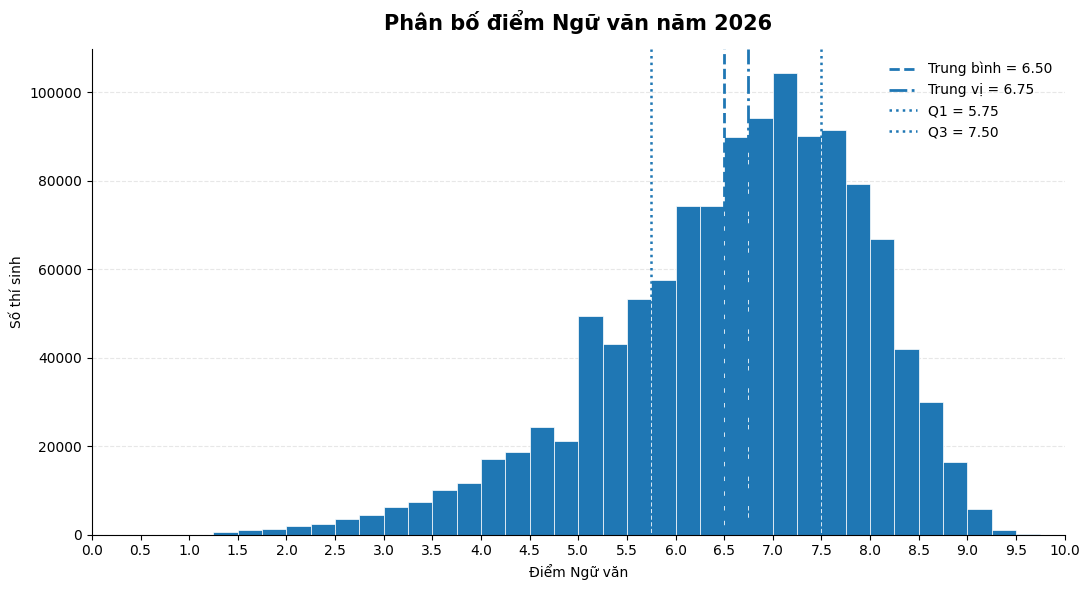

In [12]:
import numpy as np
import matplotlib.pyplot as plt

query_bieu_do_van = r"""
    SELECT CAST(NguVan AS FLOAT) AS NguVan
    FROM dbo.du_lieu_diem_thi_2026
    WHERE NguVan IS NOT NULL
"""

diem_van_plot = pd.read_sql(query_bieu_do_van, engine)["NguVan"].dropna()

mean_van = diem_van_plot.mean()
median_van = diem_van_plot.median()
q1_van = diem_van_plot.quantile(0.25)
q3_van = diem_van_plot.quantile(0.75)

fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(
    diem_van_plot,
    bins=np.arange(0, 10.26, 0.25),
    edgecolor="white",
    linewidth=0.5
)

ax.axvline(mean_van, linestyle="--", linewidth=2,
           label=f"Trung bình = {mean_van:.2f}")
ax.axvline(median_van, linestyle="-.", linewidth=2,
           label=f"Trung vị = {median_van:.2f}")
ax.axvline(q1_van, linestyle=":", linewidth=1.8,
           label=f"Q1 = {q1_van:.2f}")
ax.axvline(q3_van, linestyle=":", linewidth=1.8,
           label=f"Q3 = {q3_van:.2f}")

ax.set_title("Phân bố điểm Ngữ văn năm 2026", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Điểm Ngữ văn")
ax.set_ylabel("Số thí sinh")
ax.set_xlim(0, 10)
ax.set_xticks(np.arange(0, 10.5, 0.5))
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(frameon=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()


### 4.3. Box plot và ngoại lai môn Ngữ văn

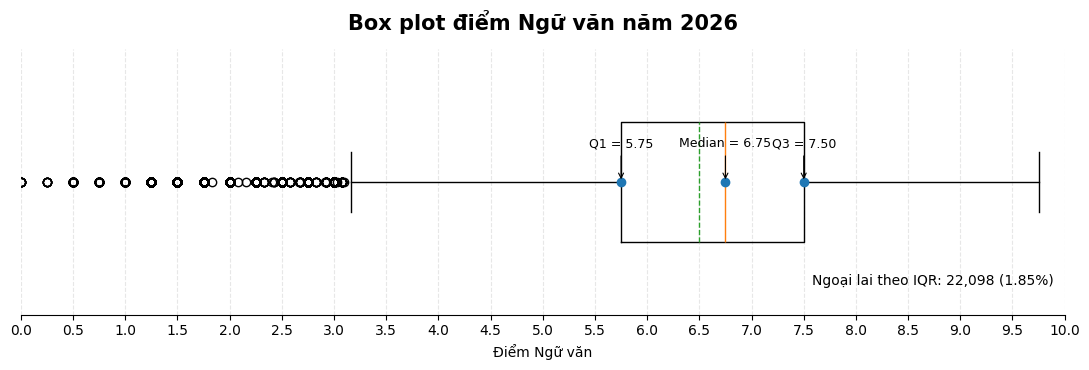

In [13]:
iqr_van = q3_van - q1_van
nguong_duoi_van = q1_van - 1.5 * iqr_van
nguong_tren_van = q3_van + 1.5 * iqr_van
so_ngoai_lai_van = int(
    ((diem_van_plot < nguong_duoi_van) | (diem_van_plot > nguong_tren_van)).sum()
)
ty_le_ngoai_lai_van = so_ngoai_lai_van / len(diem_van_plot) * 100

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.boxplot(
    diem_van_plot,
    vert=False,
    widths=0.45,
    showmeans=True,
    meanline=True,
    showfliers=True
)

ax.scatter(
    [q1_van, median_van, q3_van],
    [1, 1, 1],
    zorder=3
)

for x, nhan in [
    (q1_van, f"Q1 = {q1_van:.2f}"),
    (median_van, f"Median = {median_van:.2f}"),
    (q3_van, f"Q3 = {q3_van:.2f}")
]:
    ax.annotate(
        nhan,
        xy=(x, 1),
        xytext=(0, 25),
        textcoords="offset points",
        ha="center",
        arrowprops={"arrowstyle": "->", "linewidth": 0.8},
        fontsize=9
    )

ax.text(
    0.99,
    0.10,
    f"Ngoại lai theo IQR: {so_ngoai_lai_van:,} ({ty_le_ngoai_lai_van:.2f}%)",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10
)

ax.set_title("Box plot điểm Ngữ văn năm 2026", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Điểm Ngữ văn")
ax.set_yticks([])
ax.set_xlim(0, 10)
ax.set_xticks(np.arange(0, 10.5, 0.5))
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()


#### Kết luận môn Ngữ văn

Trong tổng số **1.208.863 thí sinh**, có **1.197.227 thí sinh có điểm Ngữ văn** và khoảng **11.636 thí sinh thiếu điểm Ngữ văn**.

Các chỉ số chính gồm:

- điểm trung bình: khoảng **6,4972**;
- Q1: **5,75**;
- trung vị: **6,75**;
- Q3: **7,50**;
- IQR: **1,75**;
- ngưỡng dưới IQR: **3,125**;
- ngưỡng trên IQR: **10,125**.

Khoảng 50% thí sinh có điểm Ngữ văn từ **5,75 đến 7,50**. IQR của Ngữ văn nhỏ hơn IQR môn Toán, cho thấy phần 50% điểm trung tâm của Ngữ văn tập trung trong một khoảng hẹp hơn.

Trung vị cao hơn trung bình khoảng 0,2528 điểm, cho thấy các mức điểm thấp đang kéo trung bình xuống và phân phối có xu hướng lệch nhẹ về phía điểm thấp.

Giới hạn IQR được tính như sau:

\[
\text{Ngưỡng dưới}=5,75-1,5\times1,75=3,125
\]

\[
\text{Ngưỡng trên}=7,50+1,5\times1,75=10,125
\]

Có **22.098 bài thi** được xác định là ngoại lai theo quy tắc IQR, chiếm khoảng **1,85%** số bài Ngữ văn hợp lệ. Các ngoại lai chủ yếu nằm ở phía điểm thấp.

Một điểm dưới 3,125 vẫn có thể là kết quả thi hợp lệ. Vì vậy, cần phân biệt **ngoại lai thống kê** với **dữ liệu sai** và không nên tự động xóa các bài thi này nếu chưa kiểm tra quy tắc nghiệp vụ.

## 5. Phân tích xác suất thực nghiệm

### 5.1. Xác suất điểm Toán dưới 5

\[
P(\text{Toán}<5)

\frac{\text{Số thí sinh có điểm Toán dưới 5}}
{\text{Tổng số thí sinh có điểm Toán}}
\]

Các bản ghi `Toan IS NULL` không nằm trong mẫu số vì chưa có điểm quan sát thực tế.

In [14]:
DANH_SACH_HS_THAP_HON_5 = r"""
     WITH A AS (
              SELECT 
                  COUNT(CAST(Toan AS FLOAT)) AS BAI_THI
              FROM 
                  dbo.du_lieu_diem_thi_2026
              WHERE 
                  Toan <5
              ),
        B AS (
              SELECT
                  COUNT(CAST(Toan AS FLOAT)) AS Toan
              FROM
                  dbo.du_lieu_diem_thi_2026
            ),
       C AS (
       SELECT 'HS'='DIEM<5',BAI_THI FROM A 
       UNION ALL         
       SELECT 'HS'='DIEM_CHUNG', TOAN  FROM B
            )
       SELECT
            * 
        FROM C
            """
BANG_DANH_GIA=pd.read_sql(DANH_SACH_HS_THAP_HON_5,engine)
print(BANG_DANH_GIA)
ti_le_toan=round((BANG_DANH_GIA['BAI_THI'][0]/BANG_DANH_GIA['BAI_THI'][1]*100),3)
print(f'Tỉ lệ học sinh dưới 5 điểm toán {ti_le_toan}%')

           HS  BAI_THI
0      DIEM<5   452838
1  DIEM_CHUNG  1192437
Tỉ lệ học sinh dưới 5 điểm toán 37.976%


#### Kết luận xác suất môn Toán

Có **452.838 thí sinh dưới 5 điểm Toán** trên tổng số **1.192.437 thí sinh có điểm Toán**.

\[
P(\text{Toán}<5)
=
\frac{452.838}{1.192.437}\times100
\approx37,976\%
\]

Nếu chọn ngẫu nhiên một thí sinh trong nhóm đã có điểm Toán, xác suất thí sinh đó dưới 5 điểm là khoảng **37,976%**, tương đương gần **38 trên 100 thí sinh**.

Đây là xác suất thực nghiệm từ dữ liệu năm 2026, không phải xác suất lý thuyết và không đảm bảo giữ nguyên trong các năm khác.

### 5.2. Xác suất điểm Ngữ văn dưới 5

Các bản ghi `NguVan IS NULL` không nằm trong mẫu số vì chưa có điểm quan sát thực tế.

In [15]:
DANH_SACH_HS_THAP_HON_5 = r"""
      WITH A AS (
              SELECT 
                  COUNT(CAST(NGUVAN AS FLOAT)) AS BAI_THI
              FROM 
                  dbo.du_lieu_diem_thi_2026
              WHERE 
                  NGUVAN <5
              ),
        B AS (
              SELECT
                  COUNT(CAST(NGUVAN AS FLOAT)) AS NGUVAN
              FROM
                  dbo.du_lieu_diem_thi_2026
            ),
       C AS (
       SELECT 'HS'='DIEM<5',BAI_THI FROM A 
       UNION ALL         
       SELECT 'HS'='DIEM_CHUNG', NGUVAN  FROM B
            )
       SELECT
            * 
        FROM C
            """
BANG_DANH_GIA_VAN=pd.read_sql(DANH_SACH_HS_THAP_HON_5,engine)
print(BANG_DANH_GIA_VAN)
ti_le_van=round((BANG_DANH_GIA_VAN['BAI_THI'][0]/BANG_DANH_GIA_VAN['BAI_THI'][1]*100),3)
print(f'Tỉ lệ học sinh dưới 5 điểm văn : {ti_le_van}%')

           HS  BAI_THI
0      DIEM<5   132685
1  DIEM_CHUNG  1197227
Tỉ lệ học sinh dưới 5 điểm văn : 11.083%


#### Kết luận xác suất môn Ngữ văn

Có **132.685 thí sinh dưới 5 điểm Ngữ văn** trên tổng số **1.197.227 thí sinh có điểm Ngữ văn**.

\[
P(\text{Ngữ văn}<5)
=
\frac{132.685}{1.197.227}\times100
\approx11,083\%
\]

Nếu chọn ngẫu nhiên một thí sinh trong nhóm đã có điểm Ngữ văn, xác suất thí sinh đó dưới 5 điểm là khoảng **11,083%**, tương đương gần **11 trên 100 thí sinh**.

#### So sánh xác suất điểm dưới 5 giữa hai môn

- Toán dưới 5: **37,976%**.
- Ngữ văn dưới 5: **11,083%**.

Chênh lệch giữa hai tỷ lệ là:

\[
37,976\%-11,083\%=26,893\text{ điểm phần trăm}
\]

Xét theo tỷ số:

\[
\frac{37,976}{11,083}\approx3,43
\]

Tỷ lệ thí sinh dưới 5 môn Toán cao gấp khoảng **3,43 lần** môn Ngữ văn trong tập dữ liệu này. Kết quả cho thấy điểm thấp xuất hiện phổ biến hơn ở môn Toán.

Tuy nhiên, chưa thể chỉ dựa vào tỷ lệ này để kết luận đề Toán khó hơn đề Ngữ văn. Sự khác biệt có thể liên quan đến cấu trúc đề, phương pháp chấm, mức độ phân hóa và đặc điểm năng lực của thí sinh.

### 5.3. Phân nhóm đồng thời điểm Toán và Ngữ văn

Các thí sinh có đủ cả hai điểm được chia thành 9 nhóm không trùng lặp theo ba mức `< 5`, `= 5` và `> 5`.

In [16]:
CHECK_XAC_XUAT_TT=f'''
     	WITH TOAN_VAN AS 
        		(	
        		SELECT 
        			COUNT(CHECK_BAI) AS TOAN_VAN_DUOI_5 
        		FROM
        			(
        			SELECT 
        				TOAN,
        				NGUVAN,
        				CASE 
        					WHEN TOAN IS NULL AND NGUVAN IS NULL THEN 'THIEU_2_MON'
        					WHEN TOAN IS NULL  THEN 'THIEU_TOAN'
        					WHEN NGUVAN IS NULL  THEN 'THIEU_VAN'
        					ELSE 'DAY_DU'
        				END AS CHECK_BAI
        			FROM
        				du_lieu_diem_thi_2026
        			WHERE 
        				TOAN <5 AND NGUVAN<5
        				)AS ABCV),
        
        		TOAN_5_VAN AS
        				(	
        			SELECT 
        				COUNT(CHECK_BAI) AS TOAN_5_VAN_5
        			FROM
        				(
        				SELECT 
        					TOAN,
        					NGUVAN,
        					CASE 
        						WHEN TOAN IS NULL AND NGUVAN IS NULL THEN 'THIEU_2_MON'
        						WHEN TOAN IS NULL  THEN 'THIEU_TOAN'
        						WHEN NGUVAN IS NULL  THEN 'THIEU_VAN'
        						ELSE 'DAY_DU'
        					END AS CHECK_BAI
        				FROM
        					du_lieu_diem_thi_2026
        				WHERE 
        					TOAN >5 AND NGUVAN<5
        					)AS ABCV1),
        
        		TOAN_VAN_5 AS 
        				(	
        			SELECT 
        				COUNT(CHECK_BAI) AS TOAN_DUOI_5_VAN_TREN_5 
        			FROM
        				(
        				SELECT 
        					TOAN,
        					NGUVAN,
        					CASE 
        						WHEN TOAN IS NULL AND NGUVAN IS NULL THEN 'THIEU_2_MON'
        						WHEN TOAN IS NULL  THEN 'THIEU_TOAN'
        						WHEN NGUVAN IS NULL  THEN 'THIEU_VAN'
        						ELSE 'DAY_DU'
        					END AS CHECK_BAI
        				FROM
        					du_lieu_diem_thi_2026
        				WHERE 
        					TOAN <5 AND NGUVAN>5
        					) AS ABCV2),
        
        		_TOAN_VAN AS 
        			(
        			SELECT 
        				COUNT(CHECK_BAI) AS TOAN_VAN_TREN_5 
        			FROM 
        				(
        				SELECT 
        					TOAN,
        					NGUVAN,
        					CASE 
        						WHEN TOAN IS NULL AND NGUVAN IS NULL THEN 'THIEU_2_MON'
        						WHEN TOAN IS NULL  THEN 'THIEU_TOAN'
        						WHEN NGUVAN IS NULL  THEN 'THIEU_VAN'
        						ELSE 'DAY_DU'
        					END AS CHECK_BAI
        				FROM
        					du_lieu_diem_thi_2026
        				WHERE 
        					TOAN >5 AND NGUVAN>5) AS ABC
        				),
                        
        		BANG_5 AS 
        		(
        		SELECT 
        			COUNT(*) AS BAI_THI_5D
        		FROM 
        			du_lieu_diem_thi_2026
        		WHERE 
        			TOAN=5 AND NGUVAN=5
        			),
        
        		BAI_THI AS 
        		(
        		SELECT 
        			COUNT(*) AS TONG_BAI_THI
        		FROM 
        			du_lieu_diem_thi_2026
        		WHERE 
        			TOAN IS NOT NULL AND NGUVAN IS NOT NULL
        			),
        
        		TOAN_5_VAN_TREN_5 AS
        		(
        			SELECT COUNT(*) AS TONG
        			FROM du_lieu_diem_thi_2026
        			WHERE TOAN = 5
        			  AND NGUVAN > 5
        		),
        
        		TOAN_5_VAN_DUOI_5 AS
        		(
        			SELECT COUNT(*) AS TONG
        			FROM du_lieu_diem_thi_2026
        			WHERE TOAN = 5
        			  AND NGUVAN < 5
        		),
        
        		TOAN_TREN_5_VAN_5 AS
        		(
        			SELECT COUNT(*) AS TONG
        			FROM du_lieu_diem_thi_2026
        			WHERE TOAN > 5
        			  AND NGUVAN = 5
        		),
        
        		TOAN_DUOI_5_VAN_5 AS
        		(
        			SELECT COUNT(*) AS TONG
        			FROM du_lieu_diem_thi_2026
        			WHERE TOAN < 5
        			  AND NGUVAN = 5
        		)
        
        SELECT 
        	THONGTIN,
        	TOAN_VAN_TREN_5 AS TONG
        FROM 
        		(
        		SELECT THONGTIN='TOAN VAN TREN 5',* FROM _TOAN_VAN
        
        		UNION ALL
        
        		SELECT THONGTIN='TOAN VAN NHO HON 5',* FROM TOAN_VAN
        
        		UNION ALL
        
        		SELECT THONGTIN='TOAN > 5 AND VAN < 5',* FROM TOAN_5_VAN
        
        		UNION ALL
        
        		SELECT THONGTIN='TOAN < 5 AND VAN > 5',* FROM TOAN_VAN_5
        
        		UNION ALL
        
        		SELECT THONGTIN='TOAN = 5 AND VAN = 5',* FROM BANG_5
        
        		UNION ALL
        
        		SELECT THONGTIN='TOAN = 5 AND VAN > 5',* FROM TOAN_5_VAN_TREN_5
        
        		UNION ALL
        
        		SELECT THONGTIN='TOAN = 5 AND VAN < 5',* FROM TOAN_5_VAN_DUOI_5
        
        		UNION ALL
        
        		SELECT THONGTIN='TOAN > 5 AND VAN = 5',* FROM TOAN_TREN_5_VAN_5
        
        		UNION ALL
        
        		SELECT THONGTIN='TOAN < 5 AND VAN = 5',* FROM TOAN_DUOI_5_VAN_5
        
        		UNION ALL
        
        		SELECT THONGTIN='TOAN BO BAI THI',* FROM BAI_THI
        	
        				) AS BBCV
                        '''
CHECK_SX_5=pd.read_sql(CHECK_XAC_XUAT_TT,engine)
CHECK_SX_5		


,THONGTIN,TONG
0,TOAN VAN TREN 5,637019
1,TOAN VAN NHO HON 5,100025
2,TOAN > 5 AND VAN < 5,25682
3,TOAN < 5 AND VAN > 5,320224
4,TOAN = 5 AND VAN = 5,2233
5,TOAN = 5 AND VAN > 5,45035
6,TOAN = 5 AND VAN < 5,4463
7,TOAN > 5 AND VAN = 5,14937
8,TOAN < 5 AND VAN = 5,31255
9,TOAN BO BAI THI,1180873


In [17]:
tong_bai_thi = CHECK_SX_5.loc[
    CHECK_SX_5['THONGTIN'] == 'TOAN BO BAI THI',
    'TONG'
].iloc[0]

CHECK_SX_5['PHAN_TRAM'] = (
    CHECK_SX_5['TONG'] / tong_bai_thi * 100
).round(2)

CHECK_SX_5

,THONGTIN,TONG,PHAN_TRAM
0,TOAN VAN TREN 5,637019,53.94
1,TOAN VAN NHO HON 5,100025,8.47
2,TOAN > 5 AND VAN < 5,25682,2.17
3,TOAN < 5 AND VAN > 5,320224,27.12
4,TOAN = 5 AND VAN = 5,2233,0.19
5,TOAN = 5 AND VAN > 5,45035,3.81
6,TOAN = 5 AND VAN < 5,4463,0.38
7,TOAN > 5 AND VAN = 5,14937,1.26
8,TOAN < 5 AND VAN = 5,31255,2.65
9,TOAN BO BAI THI,1180873,100.00


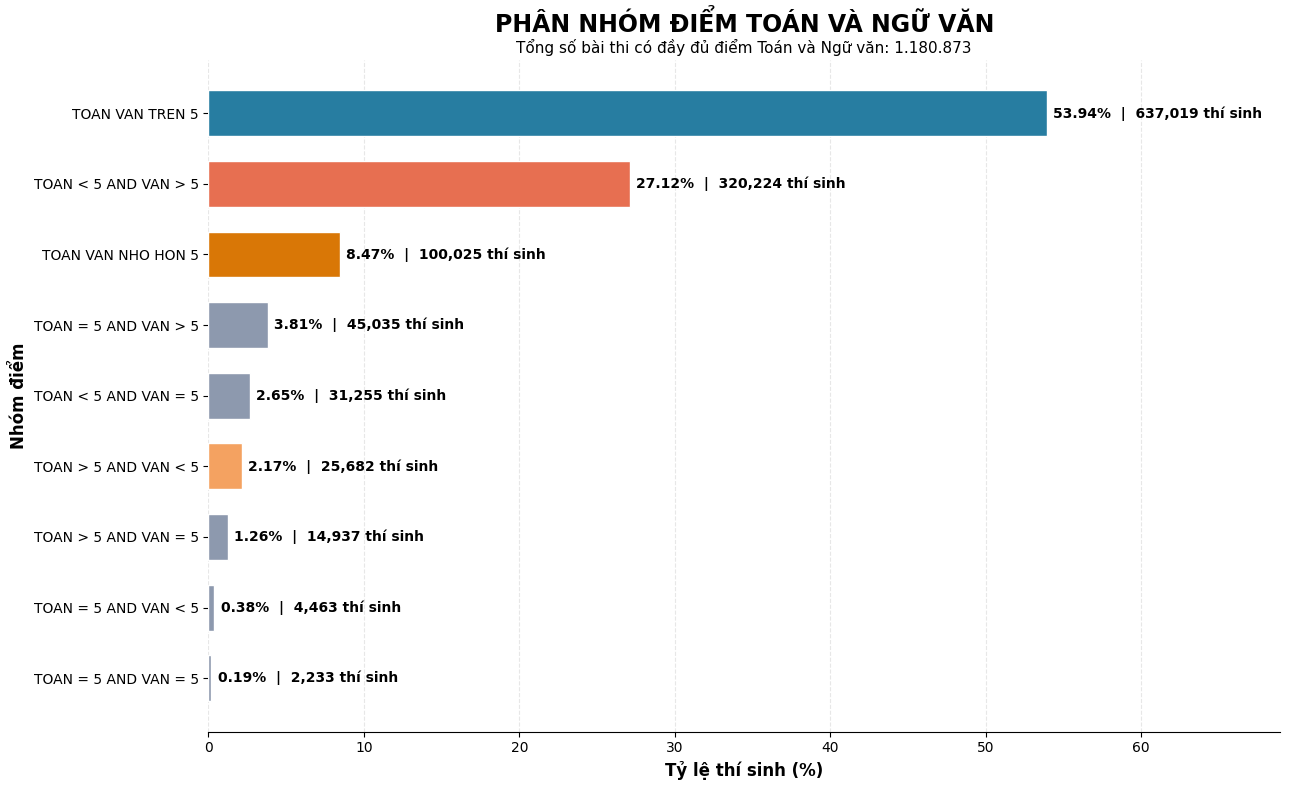

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Bỏ dòng tổng bài thi vì dòng này luôn bằng 100%
df_plot = CHECK_SX_5[
    CHECK_SX_5['THONGTIN'] != 'TOAN BO BAI THI'
].copy()

# Sắp xếp từ nhỏ đến lớn để nhóm lớn nhất nằm trên cùng
df_plot = df_plot.sort_values(
    by='PHAN_TRAM',
    ascending=True
)

# Chọn màu nhẹ, không lòe loẹt
colors = []

for nhom in df_plot['THONGTIN']:
    if '= 5' in nhom:
        colors.append('#8D99AE')       # Xám xanh: có điểm bằng 5
    elif 'NHO HON 5' in nhom:
        colors.append('#D97706')       # Cam: cả hai môn dưới 5
    elif 'TOAN < 5' in nhom:
        colors.append('#E76F51')       # Đỏ cam: Toán dưới 5
    elif 'VAN < 5' in nhom:
        colors.append('#F4A261')       # Cam nhạt: Văn dưới 5
    else:
        colors.append('#277DA1')       # Xanh: cả hai môn trên 5

fig, ax = plt.subplots(figsize=(13, 8))

bars = ax.barh(
    df_plot['THONGTIN'],
    df_plot['PHAN_TRAM'],
    color=colors,
    edgecolor='white',
    height=0.65
)

# Ghi phần trăm và số lượng cuối mỗi cột
for bar, phan_tram, tong in zip(
    bars,
    df_plot['PHAN_TRAM'],
    df_plot['TONG']
):
    ax.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f'{phan_tram:.2f}%  |  {tong:,.0f} thí sinh',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    'PHÂN NHÓM ĐIỂM TOÁN VÀ NGỮ VĂN',
    fontsize=17,
    fontweight='bold',
    pad=20
)

ax.text(
    0.5,
    1.01,
    'Tổng số bài thi có đầy đủ điểm Toán và Ngữ văn: 1.180.873',
    transform=ax.transAxes,
    ha='center',
    fontsize=11
)

ax.set_xlabel(
    'Tỷ lệ thí sinh (%)',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Nhóm điểm',
    fontsize=12,
    fontweight='bold'
)

# Đường lưới dọc giúp so sánh
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

# Đặt giới hạn để đủ chỗ ghi số
ax.set_xlim(
    0,
    df_plot['PHAN_TRAM'].max() + 15
)

# Xóa viền thừa
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

### Nhận xét phân nhóm điểm Toán và Ngữ văn

Trong tổng số **1.180.873 thí sinh có đầy đủ cả hai điểm**:

- **637.019 thí sinh** có cả Toán và Ngữ văn trên 5, chiếm **53,94%** — đây là nhóm lớn nhất;
- **320.224 thí sinh** có Toán dưới 5 nhưng Ngữ văn trên 5, chiếm **27,12%** — đứng thứ hai;
- **100.025 thí sinh** dưới 5 ở cả hai môn, chiếm **8,47%**;
- **25.682 thí sinh** có Toán trên 5 nhưng Ngữ văn dưới 5, chiếm **2,17%**.

Nhóm Toán dưới 5 nhưng Ngữ văn trên 5 lớn hơn nhóm ngược lại khoảng:

\[
\frac{27,12}{2,17}\approx12,5\text{ lần}
\]

Kết quả này thống nhất với phân tích xác suất: điểm dưới 5 xuất hiện phổ biến hơn ở môn Toán.

Các trường hợp có ít nhất một môn bằng đúng 5 gồm:

- Toán = 5, Ngữ văn > 5: **45.035 thí sinh**, chiếm **3,81%**;
- Toán < 5, Ngữ văn = 5: **31.255 thí sinh**, chiếm **2,65%**;
- Toán > 5, Ngữ văn = 5: **14.937 thí sinh**, chiếm **1,26%**;
- Toán = 5, Ngữ văn < 5: **4.463 thí sinh**, chiếm **0,38%**;
- cả hai môn = 5: **2.233 thí sinh**, chiếm **0,19%**.

Tổng các nhóm có ít nhất một môn bằng 5 là **97.923 thí sinh**, tương đương khoảng **8,29%**.

### Kiểm tra tính đầy đủ của việc phân nhóm

\[
637.019+100.025+25.682+320.224+2.233+45.035+4.463+14.937+31.255
=1.180.873
\]

Tổng số lượng của 9 nhóm bằng đúng tổng số thí sinh có đủ hai điểm. Như vậy, các nhóm không bị trùng lặp và không bỏ sót dữ liệu.

Tổng tỷ lệ hiển thị có thể bằng **99,99%** thay vì đúng 100% do làm tròn từng tỷ lệ đến hai chữ số thập phân.

## 6. Mối liên hệ giữa điểm Toán và Ngữ văn

Hệ số Pearson đo chiều và mức độ liên hệ tuyến tính giữa hai môn. Chỉ các thí sinh có đầy đủ cả hai điểm được đưa vào phép tính.

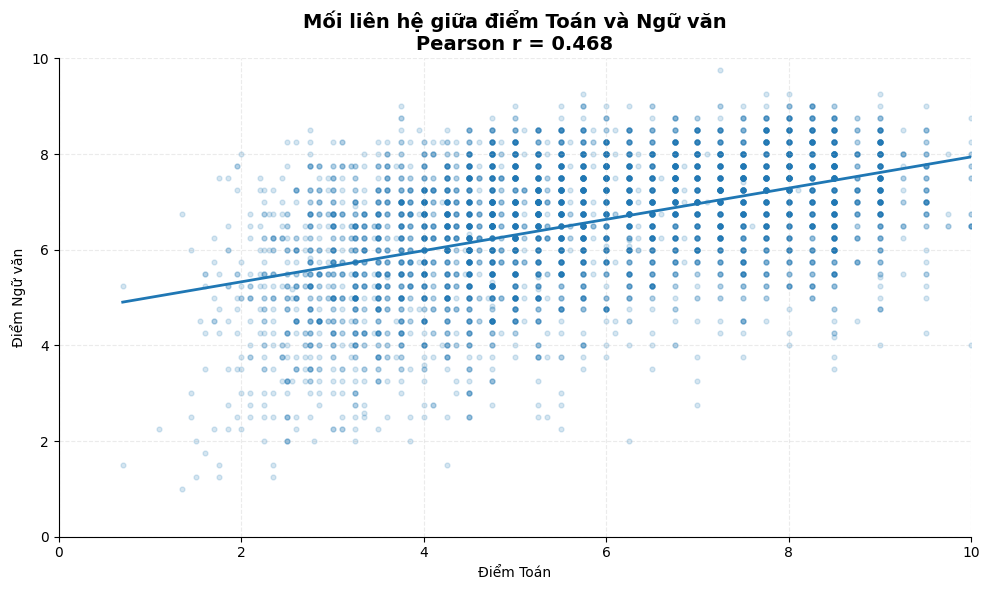

Hệ số tương quan Pearson: 0.4676


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

query = r"""
    SELECT
        CAST(Toan AS FLOAT) AS Toan,
        CAST(NguVan AS FLOAT) AS NguVan
    FROM dbo.du_lieu_diem_thi_2026
    WHERE Toan IS NOT NULL
      AND NguVan IS NOT NULL
"""

df_pearson = pd.read_sql(query, engine)

# Tính Pearson trên toàn bộ dữ liệu
r = df_pearson["Toan"].corr(df_pearson["NguVan"])

# Chỉ lấy mẫu để vẽ cho nhẹ
df_plot = df_pearson.sample(
    n=min(5000, len(df_pearson)),
    random_state=42
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df_plot["Toan"],
    df_plot["NguVan"],
    s=12,
    alpha=0.18
)

# Đường xu hướng
he_so_goc, he_so_chan = np.polyfit(
    df_plot["Toan"],
    df_plot["NguVan"],
    1
)

x_line = np.linspace(
    df_plot["Toan"].min(),
    df_plot["Toan"].max(),
    100
)

y_line = he_so_goc * x_line + he_so_chan

ax.plot(
    x_line,
    y_line,
    linewidth=2
)

ax.set_title(
    f"Mối liên hệ giữa điểm Toán và Ngữ văn\nPearson r = {r:.3f}",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Điểm Toán")
ax.set_ylabel("Điểm Ngữ văn")
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.grid(linestyle="--", alpha=0.25)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

print(f"Hệ số tương quan Pearson: {r:.4f}")

### Kết luận về tương quan Pearson

Hệ số tương quan Pearson giữa điểm Toán và Ngữ văn là:

\[
r=0,4676
\]

Giá trị dương cho thấy hai môn có mối tương quan thuận: thí sinh có điểm Toán cao thường có xu hướng đạt điểm Ngữ văn cao hơn. Mức khoảng 0,47 thể hiện mối liên hệ tuyến tính ở mức trung bình, chưa đủ mạnh để dự đoán chính xác môn này chỉ từ môn kia.

Biểu đồ cho thấy các điểm vẫn phân tán khá rộng quanh đường xu hướng. Tại cùng một mức điểm Toán có thể xuất hiện nhiều mức điểm Ngữ văn khác nhau.

Hệ số Pearson được tính trên toàn bộ **1.180.873 thí sinh có đủ hai điểm**. Biểu đồ chỉ lấy mẫu tối đa **5.000 thí sinh** để dễ quan sát và giảm thời gian vẽ; việc lấy mẫu để trực quan hóa không làm thay đổi hệ số đã tính trên toàn bộ dữ liệu.

Tương quan không chứng minh quan hệ nguyên nhân – kết quả. Không thể kết luận điểm Toán cao làm điểm Ngữ văn tăng hoặc ngược lại.

## 7. Phân tích thử nghiệm nhóm thí sinh thiếu điểm Toán

Phần này giữ nguyên phép tính `mon_conlai = TongDiem / 2` để kiểm tra một giả định thử nghiệm. Kết quả chỉ mang tính thăm dò, không phải xếp loại học lực chính thức, vì `TongDiem` có thể được tạo từ số lượng môn khác nhau.

In [20]:
query_1= r'''
    select 
         tongdiem,
        (tongdiem / 2) as mon_conlai,
       case 
         when (tongdiem / 2) <5 then 'yeu'
         when (tongdiem / 2) between 5 and 6.4 then 'TB'
         when (tongdiem / 2) between 6.5 and 7.9 then 'kha' 
         else 'gioi'
       end as rank
    from 
        [diem_thi_thpt].[dbo].[du_lieu_diem_thi_2026]
    where toan is null'''
rank_mon_con_lai=pd.read_sql(query_1,engine)
rank_mon_con_lai

,tongdiem,mon_conlai,rank
0,8.25,4.125,yeu
1,7.00,3.500,yeu
2,8.50,4.250,yeu
3,7.50,3.750,yeu
4,8.00,4.000,yeu
...,...,...,...
16421,23.10,11.550,gioi
16422,19.60,9.800,gioi
16423,22.75,11.375,gioi
16424,19.00,9.500,gioi


In [21]:
rank_mon_con_lai['rank'].value_counts()
x=rank_mon_con_lai['rank'].value_counts()

xep_loai=x.index
so_luong=x.values
print(xep_loai,so_luong)

Index(['gioi', 'kha', 'yeu', 'TB'], dtype='object', name='rank') [10479  2556  1937  1454]


In [22]:
data = {
    "xep_loai": xep_loai,
    "so_luong": so_luong
}

df = pd.DataFrame(data)
tong = df["so_luong"].sum()
df["ty_le_%"] = (df["so_luong"] / tong * 100).round(2)

print("Tổng số:", tong)
print(df)

Tổng số: 16426
  xep_loai  so_luong  ty_le_%
0     gioi     10479    63.80
1      kha      2556    15.56
2      yeu      1937    11.79
3       TB      1454     8.85


### 7.1. Biểu đồ phân bố nhóm xếp loại thử nghiệm

Các nhóm được sắp xếp theo thứ tự **Yếu → Trung bình → Khá → Giỏi**. Nhãn trên cột thể hiện đồng thời số lượng và tỷ lệ.

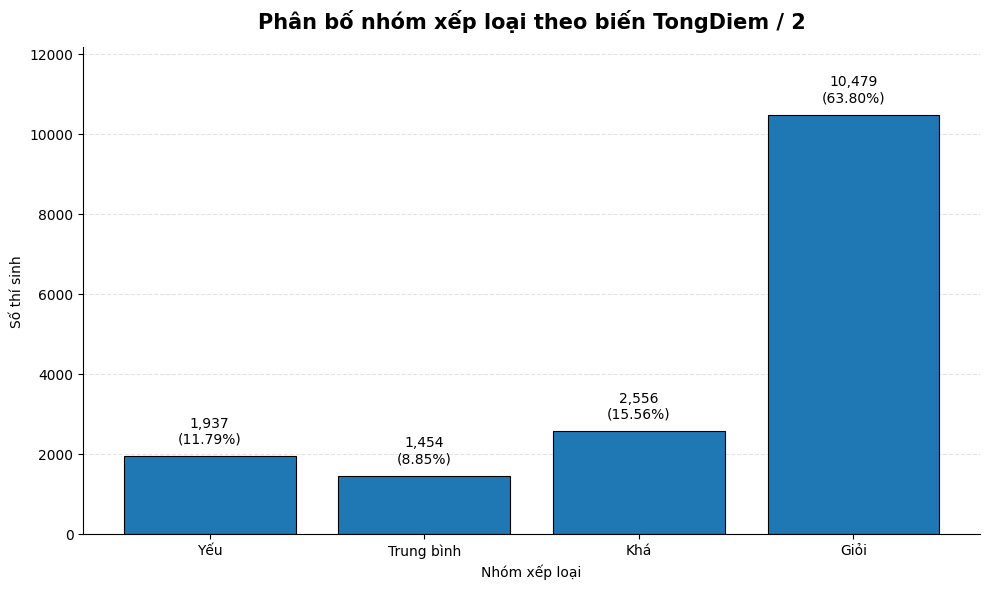

In [23]:
import matplotlib.pyplot as plt

# Giữ nguyên kết quả rank_mon_con_lai đã tính ở phần trên
thu_tu_rank = ["yeu", "TB", "kha", "gioi"]
ten_hien_thi = {
    "yeu": "Yếu",
    "TB": "Trung bình",
    "kha": "Khá",
    "gioi": "Giỏi"
}

phan_bo_rank = (
    rank_mon_con_lai["rank"]
    .value_counts()
    .reindex(thu_tu_rank, fill_value=0)
    .rename_axis("xep_loai")
    .reset_index(name="so_luong")
)

phan_bo_rank["ty_le"] = (
    phan_bo_rank["so_luong"] / phan_bo_rank["so_luong"].sum() * 100
)
phan_bo_rank["nhan"] = phan_bo_rank["xep_loai"].map(ten_hien_thi)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    phan_bo_rank["nhan"],
    phan_bo_rank["so_luong"],
    edgecolor="black",
    linewidth=0.8
)

ax.set_title(
    "Phân bố nhóm xếp loại theo biến TongDiem / 2",
    fontsize=15,
    fontweight="bold",
    pad=14
)
ax.set_xlabel("Nhóm xếp loại")
ax.set_ylabel("Số thí sinh")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

muc_tang = phan_bo_rank["so_luong"].max() * 0.025
for bar, so_luong, ty_le in zip(
    bars,
    phan_bo_rank["so_luong"],
    phan_bo_rank["ty_le"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + muc_tang,
        f"{so_luong:,.0f}\n({ty_le:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_ylim(0, phan_bo_rank["so_luong"].max() * 1.16)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()


### 7.2. Kết luận thận trọng

Theo phép tính thử nghiệm hiện tại:

- Giỏi: **10.479 thí sinh**, chiếm **63,80%**;
- Khá: **2.556 thí sinh**, chiếm **15,56%**;
- Trung bình: **1.454 thí sinh**, chiếm **8,85%**;
- Yếu: **1.937 thí sinh**, chiếm **11,79%**.

Tuy nhiên, kết quả xuất hiện các giá trị `mon_conlai` lớn hơn 10, chẳng hạn **11,55**, **11,375** và **11,05**. Điểm một môn không thể lớn hơn 10, nên giả định `TongDiem` luôn là tổng của đúng hai môn không phù hợp với toàn bộ dữ liệu.

Vì vậy, không nên dùng các tỷ lệ trên để:

- kết luận học lực;
- dự đoán đỗ hoặc trượt;
- thay thế điểm Toán bị thiếu;
- đưa ra quyết định hỗ trợ thí sinh.

Muốn phân tích chính xác cần xác định rõ các môn cấu thành `TongDiem` và số môn thực tế của từng bản ghi. Phần này nên được xem là **thử nghiệm** hoặc **phụ lục**, không sử dụng trong kết luận chính.

## 8. Hạn chế của phân tích

1. **Chưa biết nguyên nhân của dữ liệu thiếu:** `NULL` không cho biết thí sinh vắng thi, miễn thi, bị hủy kết quả hay dữ liệu bị thiếu khi thu thập.
2. **So sánh tỉnh mới chủ yếu dựa trên số lượng:** chưa chuẩn hóa theo tổng số thí sinh của từng tỉnh.
3. **Mã tỉnh chưa được chuyển thành tên tỉnh:** làm giảm khả năng đọc và diễn giải kết quả.
4. **Ngoại lai IQR không đồng nghĩa dữ liệu sai:** điểm thấp vẫn có thể là kết quả thi hợp lệ.
5. **Pearson chỉ đo quan hệ tuyến tính:** không phản ánh đầy đủ quan hệ phi tuyến và không chứng minh nhân quả.
6. **Dữ liệu mới thuộc một năm:** chưa thể xác định xu hướng tăng, giảm nếu chưa so sánh nhiều năm.
7. **Thiếu các biến giải thích:** chưa có đủ thông tin về trường học, khu vực, điều kiện học tập hoặc đặc điểm cá nhân để giải thích nguyên nhân điểm cao, thấp.
8. **Chưa có biến mục tiêu chính thức cho Machine Learning:** cần xác định rõ bài toán trước khi huấn luyện mô hình.

## 9. Kết luận tổng hợp

### Chất lượng dữ liệu

Tập dữ liệu có **1.208.863 thí sinh**. Trong đó, **16.426 thí sinh thiếu điểm Toán**, khoảng **11.636 thí sinh thiếu điểm Ngữ văn**, **72 thí sinh thiếu đồng thời hai môn** và **1.180.873 thí sinh có đủ cả hai điểm**.

### Môn Toán

Điểm Toán có trung bình khoảng **5,6516**, trung vị **5,50** và 50% điểm nằm từ **4,25 đến 7,25**. Quy tắc IQR không phát hiện ngoại lai vì giới hạn từ -0,25 đến 11,75 rộng hơn thang điểm hợp lệ.

### Môn Ngữ văn

Điểm Ngữ văn có trung bình khoảng **6,4972**, trung vị **6,75** và 50% điểm nằm từ **5,75 đến 7,50**. Có **22.098 bài**, tương đương khoảng **1,85%**, được xác định là ngoại lai theo IQR và chủ yếu nằm ở phía điểm thấp.

### Xác suất điểm dưới 5

- Toán dưới 5: **37,976%**.
- Ngữ văn dưới 5: **11,083%**.

Tỷ lệ dưới 5 môn Toán cao hơn khoảng **26,893 điểm phần trăm**, tương đương gấp khoảng **3,43 lần** môn Ngữ văn.

### Phân nhóm đồng thời hai môn

- **53,94%** có cả hai môn trên 5;
- **27,12%** có Toán dưới 5 nhưng Ngữ văn trên 5;
- **8,47%** có cả hai môn dưới 5;
- **2,17%** có Toán trên 5 nhưng Ngữ văn dưới 5;
- khoảng **8,29%** có ít nhất một môn bằng đúng 5.

Chín nhóm bao phủ đúng toàn bộ **1.180.873 thí sinh có đủ hai điểm**, không bị trùng hoặc bỏ sót.

### Mối liên hệ hai môn

Pearson bằng **0,4676**, cho thấy mối tương quan thuận ở mức trung bình. Điểm Toán và Ngữ văn có xu hướng biến động cùng chiều nhưng chưa đủ để dự đoán chính xác môn này chỉ từ môn kia.

### Kết luận cuối

Notebook đã hoàn thành các bước chính của một bài phân tích dữ liệu cơ bản: kiểm tra dữ liệu thiếu, thống kê mô tả, kiểm tra ngoại lai, so sánh xử lý `NULL`, tính xác suất, phân nhóm và phân tích tương quan.

Kết quả nổi bật nhất là điểm dưới 5 xuất hiện phổ biến hơn ở môn Toán, trong khi hơn một nửa thí sinh có điểm trên 5 ở cả hai môn. Các kết quả này là cơ sở cho phân tích sâu hơn nhưng chưa đủ để giải thích nguyên nhân hoặc kết luận chính thức về khả năng đỗ, trượt của từng thí sinh.

## 10. Hướng phát triển phân tích

### 1. Xác suất có điều kiện

Có thể tính:

\[
P(\text{Ngữ văn}<5\mid\text{Toán}<5)
\]

và:

\[
P(\text{Toán}<5\mid\text{Ngữ văn}<5)
\]

Hai xác suất này giúp đánh giá mức độ đồng thời xuất hiện điểm thấp giữa hai môn.

### 2. Phân tích theo tỉnh

Nên bổ sung tổng số thí sinh, điểm trung bình, trung vị, tỷ lệ thiếu điểm, tỷ lệ dưới 5 và độ lệch chuẩn của từng tỉnh. Khi so sánh, nên ưu tiên tỷ lệ thay vì số lượng tuyệt đối.

### 3. So sánh nhiều năm

Nếu có dữ liệu 2018–2026, có thể đánh giá xu hướng điểm trung bình, tỷ lệ dưới 5, mức phân tán và sự thay đổi tương quan giữa các môn.

### 4. Hồi quy tuyến tính

Có thể thử mô hình hồi quy giữa Toán và Ngữ văn, sau đó đánh giá bằng \(R^2\), MAE, MSE, RMSE và biểu đồ phần dư. Mô hình chỉ mang ý nghĩa phân tích, không thay thế điểm thi thật.

### 5. Machine Learning

Chỉ nên áp dụng ML sau khi xác định rõ biến mục tiêu, ví dụ:

- phân loại nguy cơ dưới 5 điểm;
- dự đoán điểm một môn;
- phân nhóm thí sinh theo nhiều môn;
- phát hiện bản ghi bất thường.

Mô hình cần được đánh giá trên tập kiểm tra riêng và không nên chỉ sử dụng Accuracy khi dữ liệu mất cân bằng.